# Extract Imaging Information from DICOM files

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pydicom import dcmread
from tqdm import tqdm
from pathlib import Path
import re
import nibabel as nib

## Get List of Current Patient IDs

Inputs

In [2]:
path_to_tsv = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Dateien/participants_04_09_24.tsv")
path_to_tfrecord_folder = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Datensatz_RGB/regensburg_slices_tfrecords/all_pats_single_slice_gray")

paths_to_check = [
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/allPatients/originalPatientFiles"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/allPatients/Rgb_Brain_Mets_manually_selected"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/allPatients/Rgb_Brain_Mets_Selected Patients"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/allPatients/Rgb_Brain_Mets_Preprocessing_0_blacklist_20240120-155725"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/brain_mets_regensburg"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/Rgb_Brain_Mets_Dataset_DICOM"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/Rgb_Brain_Mets_Revision_DICOM"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/Rgb_Brain_Mets_Revision_original/Rgb_Brain_Mets_Preprocessing_manually_selected"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/Rgb_Brain_Mets_Revision_original/Rgb_Brain_Mets_Preprocessing_01_sequencesFiltered_20240207-175808"),
    Path("/Volumes/BrainMets/Rgb_Brain_Mets/Rgb_Brain_Mets_Revision_original/Rgb_Brain_Mets_Preprocessing_0_blacklist_20240207-175513"),
    Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Datensatz_RGB/patient_correction_24_07_24/og_files"),
    Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Quirin Korrekturen/Korrekturen 01_08_24"),
    Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Quirin Korrekturen/Quirin Check_corr")
]

#Excel file with existing DICOM info
path_to_excel = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/dicomtest_full_neu.xlsx")
excel_patient_id_column = "PatientID"

Outputs

In [3]:
output_missing_only = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/dicom_info_missing_patients.xlsx")
output_combined = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/dicom_info_combined.xlsx")
output_missing_patients_list = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/missing_patients_for_dicom_extraction.xlsx")

Helper funcs

In [4]:
def extract_patient_id_from_string(text: str):
    """
    Extract first 8-digit patient ID from a string.
    Returns None if no 8-digit ID is found.
    """
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(r'(\d{8})', text)
    return match.group(1) if match else None

def normalize_patient_id(pid):
    """
    Normalizes IDs such as:
    - sub-01234567 -> 01234567
    - 1234567 -> 01234567 (only if numeric and shorter than 8 digits)
    - 12345678.0 -> 12345678
    - returns string or None
    """
    if pd.isna(pid):
        return None

    pid = str(pid).strip()

    # remove common prefix
    pid = pid.replace("sub-", "")

    # remove trailing .0 if Excel interpreted as float
    if pid.endswith(".0"):
        pid = pid[:-2]

    # keep first 8-digit ID if embedded in a longer string
    embedded = extract_patient_id_from_string(pid)
    if embedded is not None:
        return embedded

    # if it's purely numeric but shorter, zero-pad
    if pid.isdigit():
        return pid.zfill(8)

    return None

In [ ]:
# -----------------------------
# LOAD IDS
# -----------------------------
df = pd.read_csv(path_to_tsv, sep="\t")
df_ids = set(df["participant_id"].tolist())

tfr_patient_ids = {d.name for d in path_to_tfrecord_folder.iterdir() if d.is_dir()}

common_ids = df_ids.intersection(tfr_patient_ids)
clean_ids = sorted(pid.replace("sub-", "") for pid in common_ids)

print(f"TSV patients: {len(df_ids)}")
print(f"TFRecord patients: {len(tfr_patient_ids)}")
print(f"Common patients: {len(clean_ids)}")
print()

# -----------------------------
# BUILD DIRECTORY INDEX
# -----------------------------
directory_maps = {}

for base_path in paths_to_check:
    folder_map = {}  # patient_id -> list of matching folder names
    for d in base_path.iterdir():
        if not d.is_dir():
            continue
        pid = extract_patient_id_from_string(d.name)
        if pid is not None:
            folder_map.setdefault(pid, []).append(d.name)
    directory_maps[base_path.name] = folder_map


# ============================================================
# LOAD EXCEL PATIENT IDS
# ============================================================
excel_df = pd.read_excel(path_to_excel)

if excel_patient_id_column not in excel_df.columns:
    raise ValueError(
        f"Column '{excel_patient_id_column}' not found in Excel file. "
        f"Available columns: {list(excel_df.columns)}"
    )

excel_df["normalized_patient_id"] = excel_df[excel_patient_id_column].apply(normalize_patient_id)

excel_patient_ids = set(excel_df["normalized_patient_id"].dropna().tolist())

print(f"Excel rows: {len(excel_df)}")
print(f"Unique normalized Excel patient IDs: {len(excel_patient_ids)}")
print(f"Example Excel patient IDs: {list(sorted(excel_patient_ids))[:10]}")
print()



# -----------------------------
# BUILD OVERVIEW TABLE
# -----------------------------
overview_rows = []

for pid in clean_ids:
    row = {"patient_id": pid}
    found_anywhere = False

    for dir_name, folder_map in directory_maps.items():
        matches = folder_map.get(pid, [])
        row[f"{dir_name}_present"] = len(matches) > 0
        row[f"{dir_name}_folders"] = " | ".join(matches) if matches else ""
        if matches:
            found_anywhere = True

    # Excel info
    row["excel_dicom_info_present"] = pid in excel_patient_ids

    # overall flags
    row["found_in_any_folder"] = found_anywhere
    row["found_anywhere_including_excel"] = found_anywhere or (pid in excel_patient_ids)

    overview_rows.append(row)

overview_df = pd.DataFrame(overview_rows)


# ============================================================
# SUMMARY
# ============================================================
print("========== SUMMARY ==========")
print(f"Total patients in target cohort: {len(overview_df)}")
print()

for dir_name in directory_maps.keys():
    n_present = int(overview_df[f"{dir_name}_present"].sum())
    print(f"{dir_name}: {n_present}/{len(overview_df)} patients found ({n_present/len(overview_df)*100:.2f}%)")

n_excel = int(overview_df["excel_dicom_info_present"].sum())
print(f"Excel DICOM info present: {n_excel}/{len(overview_df)} patients ({n_excel/len(overview_df)*100:.2f}%)")
print()

missing_all_folders = overview_df.loc[
    ~overview_df["found_in_any_folder"], "patient_id"
].tolist()

missing_excel = overview_df.loc[
    ~overview_df["excel_dicom_info_present"], "patient_id"
].tolist()

missing_everywhere = overview_df.loc[
    ~overview_df["found_anywhere_including_excel"], "patient_id"
].tolist()

print(f"Patients missing in ALL checked folders: {len(missing_all_folders)}")
print(missing_all_folders[:30])
print()

print(f"Patients missing in Excel subset: {len(missing_excel)}")
print(missing_excel[:30])
print()

print(f"Patients missing in all folders AND not in Excel: {len(missing_everywhere)}")
print(missing_everywhere[:30])
print()

# ============================================================
# EXTRA CHECKS
# ============================================================
# Patients present in Excel but not part of your clean_ids cohort
excel_not_in_cohort = sorted(excel_patient_ids - set(clean_ids))
print(f"Excel patient IDs not in target cohort: {len(excel_not_in_cohort)}")
print(excel_not_in_cohort[:30])
print()

# Patients found only in Excel but not in any folder
only_in_excel = overview_df.loc[
    (~overview_df["found_in_any_folder"]) & (overview_df["excel_dicom_info_present"]),
    "patient_id"
].tolist()
print(f"Patients found only in Excel, not in any checked folder: {len(only_in_excel)}")
print(only_in_excel[:30])
print()

# Patients found in folders but missing in Excel
folders_but_not_excel = overview_df.loc[
    (overview_df["found_in_any_folder"]) & (~overview_df["excel_dicom_info_present"]),
    "patient_id"
].tolist()
print(f"Patients found in folders but missing in Excel: {len(folders_but_not_excel)}")
print(folders_but_not_excel[:30])
print()


# ============================================================
# EXTRA CHECKS
# ============================================================
# Patients present in Excel but not part of your clean_ids cohort
excel_not_in_cohort = sorted(excel_patient_ids - set(clean_ids))
print(f"Excel patient IDs not in target cohort: {len(excel_not_in_cohort)}")
print(excel_not_in_cohort[:30])
print()

# Patients found only in Excel but not in any folder
only_in_excel = overview_df.loc[
    (~overview_df["found_in_any_folder"]) & (overview_df["excel_dicom_info_present"]),
    "patient_id"
].tolist()
print(f"Patients found only in Excel, not in any checked folder: {len(only_in_excel)}")
print(only_in_excel[:30])
print()

# Patients found in folders but missing in Excel
folders_but_not_excel = overview_df.loc[
    (overview_df["found_in_any_folder"]) & (~overview_df["excel_dicom_info_present"]),
    "patient_id"
].tolist()
print(f"Patients found in folders but missing in Excel: {len(folders_but_not_excel)}")
print(folders_but_not_excel[:30])
print()


# ============================================================
# OPTIONAL: patients found only in one specific folder source
# ============================================================
for dir_name in directory_maps.keys():
    only_here_mask = overview_df[f"{dir_name}_present"].copy()
    for other_dir in directory_maps.keys():
        if other_dir != dir_name:
            only_here_mask &= ~overview_df[f"{other_dir}_present"]

    only_here = overview_df.loc[only_here_mask, "patient_id"].tolist()
    print(f"Patients found ONLY in {dir_name}: {len(only_here)}")
    print(only_here[:20])
    print()


# -----------------------------
# OPTIONAL: save results
# -----------------------------
# output_path = Path("/Users/LennartPhilipp/Desktop/patient_file_overview.xlsx")
# overview_df.to_excel(output_path, index=False)
# print()
# print(f"Saved overview to: {output_path}")

TSV patients: 473
TFRecord patients: 470
Common patients: 470

Excel rows: 6434
Unique normalized Excel patient IDs: 410
Example Excel patient IDs: ['01010015', '01015961', '01018613', '01021714', '01025630', '01031243', '01040149', '01041137', '01056884', '01064662']

========== SUMMARY ==========
Total patients in target cohort: 470

originalPatientFiles: 295/470 patients found (62.77%)
Rgb_Brain_Mets_manually_selected: 272/470 patients found (57.87%)
Rgb_Brain_Mets_Selected Patients: 273/470 patients found (58.09%)
Rgb_Brain_Mets_Preprocessing_0_blacklist_20240120-155725: 272/470 patients found (57.87%)
brain_mets_regensburg: 272/470 patients found (57.87%)
Rgb_Brain_Mets_Dataset_DICOM: 272/470 patients found (57.87%)
Rgb_Brain_Mets_Revision_DICOM: 27/470 patients found (5.74%)
Rgb_Brain_Mets_Preprocessing_manually_selected: 27/470 patients found (5.74%)
Rgb_Brain_Mets_Preprocessing_01_sequencesFiltered_20240207-175808: 27/470 patients found (5.74%)
Rgb_Brain_Mets_Preprocessing_0_bl

## Extract DICOM info into Excel Sheet

In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

from pydicom import dcmread
from pydicom.misc import is_dicom
from tqdm import tqdm


# ============================================================
# DICOM COLUMNS
# ============================================================
column_names = [
    'PatientID', 'StudyDate', 'AccessionNumber',
    'Manufacturer', 'InstitutionName',
    'StudyDescription', 'SeriesDescription', 'ProtocolName',
    'ManufacturerModelName', 'ScanningSequence', 'MRAcquisitionType',
    'SequenceName', 'SliceThickness', 'RepetitionTime', 'EchoTime',
    'MagneticFieldStrength', 'AcquisitionMatrix', 'FlipAngle',
    'Rows', 'Columns', 'PixelSpacing', 'SpacingBetweenSlices',
    'InversionTime'
]


# ============================================================
# HELPERS
# ============================================================


def make_hashable(value):
    """
    Convert list-like DICOM values to strings so drop_duplicates works reliably.
    """
    if isinstance(value, (list, tuple)):
        return str(value)
    return value


def safe_get_dicom_value(ds, field_name):
    try:
        value = ds[field_name].value
        return make_hashable(value)
    except Exception:
        return np.nan


def find_all_files(root_folder):
    """
    Return all files recursively below a folder.
    """
    return [p for p in root_folder.rglob("*") if p.is_file()]


def find_dicom_files(root_folder):
    """
    Find DICOM files recursively.
    First try pydicom.misc.is_dicom, which catches extensionless DICOM files too.
    """
    dicom_files = []
    all_files = find_all_files(root_folder)

    for f in all_files:
        try:
            if is_dicom(str(f)):
                dicom_files.append(f)
        except Exception:
            pass

    return dicom_files


def extract_dicom_rows_from_folder(folder, expected_patient_id=None):
    """
    Extract metadata rows from all DICOM files inside one patient folder.
    Optionally filter to headers whose PatientID matches expected_patient_id.
    """
    dicom_files = find_dicom_files(folder)
    rows = []

    for file in dicom_files:
        try:
            ds = dcmread(str(file), stop_before_pixels=True, force=True)
        except Exception:
            continue

        row = {c: safe_get_dicom_value(ds, c) for c in column_names}
        row["source_folder"] = str(folder)
        row["source_file"] = str(file)

        normalized_pid = normalize_patient_id(row.get("PatientID"))
        row["normalized_PatientID"] = normalized_pid

        if expected_patient_id is not None:
            # keep row if PatientID matches, or if header PatientID is missing
            if normalized_pid is not None and normalized_pid != expected_patient_id:
                continue

        rows.append(row)

    return rows


# ============================================================
# STEP 1: LOAD TARGET COHORT IDS
# ============================================================
df = pd.read_csv(path_to_tsv, sep="\t")
df_ids = set(df["participant_id"].tolist())

tfr_patient_ids = {d.name for d in path_to_tfrecord_folder.iterdir() if d.is_dir()}

common_ids = df_ids.intersection(tfr_patient_ids)
clean_ids = sorted(pid.replace("sub-", "") for pid in common_ids)

print(f"Target cohort size: {len(clean_ids)}")


# ============================================================
# STEP 2: LOAD EXISTING EXCEL + FIND MISSING PATIENTS
# ============================================================
existing_df = pd.read_excel(path_to_excel)

if excel_patient_id_column not in existing_df.columns:
    raise ValueError(
        f"Column '{excel_patient_id_column}' not found in Excel. "
        f"Available columns: {list(existing_df.columns)}"
    )

existing_df["normalized_patient_id"] = existing_df[excel_patient_id_column].apply(normalize_patient_id)
existing_excel_ids = set(existing_df["normalized_patient_id"].dropna().tolist())

missing_patient_ids = sorted(set(clean_ids) - existing_excel_ids)

print(f"Patients already covered by existing Excel: {len(existing_excel_ids.intersection(set(clean_ids)))}")
print(f"Patients missing from existing Excel: {len(missing_patient_ids)}")
print("First 20 missing:", missing_patient_ids[:20])

pd.DataFrame({"patient_id": missing_patient_ids}).to_excel(output_missing_patients_list, index=False)
print(f"Saved missing patient list to: {output_missing_patients_list}")


# ============================================================
# STEP 3: INDEX TOP-LEVEL PATIENT FOLDERS
# ============================================================
directory_maps = {}

for base_path in paths_to_check:
    folder_map = {}  # pid -> list of matching top-level folders
    for d in base_path.iterdir():
        if not d.is_dir():
            continue
        pid = extract_patient_id_from_string(d.name)
        if pid is not None:
            folder_map.setdefault(pid, []).append(d)
    directory_maps[base_path.name] = folder_map

for dir_name, folder_map in directory_maps.items():
    print(f"{dir_name}: {len(folder_map)} patient IDs indexed")


# ============================================================
# STEP 4: EXTRACT DICOM INFO FOR MISSING PATIENTS ONLY
# ============================================================
all_new_rows = []
patient_summary = []

for pid in tqdm(missing_patient_ids, desc="Processing missing patients"):
    candidate_folders = []

    for dir_name, folder_map in directory_maps.items():
        matches = folder_map.get(pid, [])
        for match in matches:
            candidate_folders.append(match)

    candidate_folders = list(dict.fromkeys(candidate_folders))  # remove duplicates, preserve order

    patient_info = {
        "patient_id": pid,
        "n_candidate_folders": len(candidate_folders),
        "candidate_folders": " | ".join(str(x) for x in candidate_folders),
        "n_dicom_rows_extracted": 0
    }

    if len(candidate_folders) == 0:
        patient_summary.append(patient_info)
        continue

    patient_rows = []

    for folder in candidate_folders:
        rows = extract_dicom_rows_from_folder(folder, expected_patient_id=pid)
        patient_rows.extend(rows)

    if len(patient_rows) > 0:
        patient_df = pd.DataFrame(patient_rows)

        # Deduplicate using same metadata columns + normalized pid
        dedup_cols = column_names + ["normalized_PatientID"]
        dedup_cols = [c for c in dedup_cols if c in patient_df.columns]

        patient_df = patient_df.loc[patient_df.astype(str).drop_duplicates(subset=dedup_cols).index]

        patient_info["n_dicom_rows_extracted"] = len(patient_df)
        all_new_rows.append(patient_df)

    patient_summary.append(patient_info)


# ============================================================
# STEP 5: BUILD SUPPLEMENTAL RESULTS
# ============================================================
patient_summary_df = pd.DataFrame(patient_summary)

if len(all_new_rows) > 0:
    new_results = pd.concat(all_new_rows, ignore_index=True)
else:
    new_results = pd.DataFrame(columns=column_names + ["source_folder", "source_file", "normalized_PatientID"])

print()
print("========== EXTRACTION SUMMARY ==========")
print(f"Missing patients total: {len(missing_patient_ids)}")
print(f"Patients with at least one extracted DICOM row: {(patient_summary_df['n_dicom_rows_extracted'] > 0).sum()}")
print(f"Patients with zero extracted rows: {(patient_summary_df['n_dicom_rows_extracted'] == 0).sum()}")
print(f"Total new metadata rows: {len(new_results)}")

# Save patient summary
summary_path = output_missing_only.with_name(output_missing_only.stem + "_patient_summary.xlsx")
patient_summary_df.to_excel(summary_path, index=False)
print(f"Saved patient summary to: {summary_path}")

# Save only newly extracted rows
new_results.to_excel(output_missing_only, index=False)
print(f"Saved new DICOM rows to: {output_missing_only}")


# ============================================================
# STEP 6: OPTIONAL - CREATE COMBINED EXCEL
# ============================================================
existing_for_merge = existing_df.copy()

if "normalized_PatientID" not in existing_for_merge.columns:
    existing_for_merge["normalized_PatientID"] = existing_for_merge[excel_patient_id_column].apply(normalize_patient_id)

combined_df = pd.concat([existing_for_merge, new_results], ignore_index=True, sort=False)

# Deduplicate across old + new
dedup_cols_combined = [c for c in column_names if c in combined_df.columns]
if "normalized_PatientID" in combined_df.columns:
    dedup_cols_combined = dedup_cols_combined + ["normalized_PatientID"]

combined_df = combined_df.loc[
    combined_df.astype(str).drop_duplicates(subset=dedup_cols_combined).index
]

combined_df.to_excel(output_combined, index=False)
print(f"Saved combined DICOM metadata to: {output_combined}")

Target cohort size: 470
Patients already covered by existing Excel: 220
Patients missing from existing Excel: 250
First 20 missing: ['01005097', '01005630', '01006290', '01009590', '01021993', '01022787', '01038520', '01055292', '01056598', '01072344', '01083248', '01098043', '01106844', '01108350', '01109318', '01111974', '01117914', '01122863', '01125016', '01134825']
Saved missing patient list to: /Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/missing_patients_for_dicom_extraction.xlsx
originalPatientFiles: 373 patient IDs indexed
Rgb_Brain_Mets_manually_selected: 319 patient IDs indexed
Rgb_Brain_Mets_Selected Patients: 321 patient IDs indexed
Rgb_Brain_Mets_Preprocessing_0_blacklist_20240120-155725: 319 patient IDs indexed
brain_mets_regensburg: 312 patient IDs indexed
Rgb_Brain_Mets_Dataset_DICOM: 312 patient IDs indexed
Rgb_Brain_Mets_Revision_DICOM: 29 patient IDs indexed
Rgb_Brain_Mets_Preprocessing_manually_selected: 29 patient IDs indexed
Rgb_Brain_Mets_Preprocessing_

Processing missing patients:  37%|███▋      | 93/250 [50:37<38:21, 14.66s/it]    /Users/LennartPhilipp/Desktop/Uni/Prowiss/Code/Brain_Mets_Classification/brain_mets_env/lib/python3.12/site-packages/pydicom/charset.py:351: UserWarning: Failed to decode byte string with encoding 'UTF8' - using replacement characters in decoded string
  warn_and_log(
Processing missing patients: 100%|██████████| 250/250 [2:00:42<00:00, 28.97s/it]   



========== EXTRACTION SUMMARY ==========
Missing patients total: 250
Patients with at least one extracted DICOM row: 246
Patients with zero extracted rows: 4
Total new metadata rows: 3948
Saved patient summary to: /Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/dicom_info_missing_patients_patient_summary.xlsx
Saved new DICOM rows to: /Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/dicom_info_missing_patients.xlsx
Saved combined DICOM metadata to: /Users/LennartPhilipp/Desktop/Uni/Prowiss/Paper/DICOM/dicom_info_combined.xlsx


### Scanner Summary

In [5]:
combined_df = pd.read_excel(output_combined)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")

# ============================================================
# PATHS
# ============================================================
output_dir = Path("/Users/LennartPhilipp/Desktop/Uni/Prowiss/Dateien/dataset_plots")
output_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================
data = pd.read_excel(output_combined, dtype=str)

# TFRecord patient IDs are the only relevant cohort
tfr_patient_ids = [d.name for d in path_to_tfrecord_folder.iterdir() if d.is_dir()]
tfr_patient_ids_clean = [pid.replace("sub-", "") for pid in tfr_patient_ids]

print("Number of TFRecord patients:", len(tfr_patient_ids_clean))
print("Example TFRecord patients:", tfr_patient_ids_clean[:5])

Number of TFRecord patients: 470
Example TFRecord patients: ['01812518', '02095303', '01729917', '02155605', '01892684']


In [9]:
# Normalize PatientID in excel
def normalize_patient_id(pid):
    if pd.isna(pid):
        return np.nan
    pid = str(pid).strip().replace("sub-", "")
    if pid.endswith(".0"):
        pid = pid[:-2]
    if pid.isdigit():
        pid = pid.zfill(8)
    return pid

data["PatientID_norm"] = data["PatientID"].apply(normalize_patient_id)

# Keep only TFRecord patients
data_selected = data.loc[data["PatientID_norm"].isin(tfr_patient_ids_clean)].copy()

print("Combined excel shape:", data.shape)
print("Filtered TFRecord cohort shape:", data_selected.shape)
print("Unique TFRecord patients in excel:", data_selected["PatientID_norm"].nunique())

# ============================================================
# CLEAN IMPORTANT COLUMNS
# ============================================================
# Manufacturer / model cleanup
data_selected.loc[data_selected["ManufacturerModelName"] == "TrioTim", "Manufacturer"] = "SIEMENS"
data_selected.loc[data_selected["Manufacturer"].isna(), "Manufacturer"] = "Unknown manufacturer"
data_selected.loc[data_selected["ManufacturerModelName"].isna(), "ManufacturerModelName"] = "Unknown model"
data_selected.loc[data_selected["ManufacturerModelName"].astype(str).str.contains("syngo", na=False), "ManufacturerModelName"] = "Unknown model"
data_selected.loc[data_selected["Manufacturer"].astype(str).str.contains("Siemens", na=False), "Manufacturer"] = "SIEMENS"

data_selected["scanner"] = (
    data_selected["Manufacturer"].astype(str).str.strip() + " " +
    data_selected["ManufacturerModelName"].astype(str).str.strip()
)

Combined excel shape: (10382, 29)
Filtered TFRecord cohort shape: (7729, 29)
Unique TFRecord patients in excel: 466


In [10]:
# PixelSpacing: take first value if stored like "[0.5, 0.5]"
def parse_first_pixel_spacing(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.strip("[]()")
    x = x.replace("'", "").replace('"', "")
    parts = [p.strip() for p in x.split(",")]
    try:
        return float(parts[0])
    except Exception:
        try:
            parts = x.split()
            return float(parts[0])
        except Exception:
            return np.nan

data_selected["PixelSpacing"] = data_selected["PixelSpacing"].apply(parse_first_pixel_spacing)

# Numeric columns
numeric_cols = [
    "MagneticFieldStrength", "SpacingBetweenSlices", "SliceThickness",
    "FlipAngle", "EchoTime", "RepetitionTime", "InversionTime",
    "Rows", "Columns"
]

for col in numeric_cols:
    data_selected[col] = pd.to_numeric(data_selected[col], errors="coerce")

data_selected["MagneticFieldStrength"] = data_selected["MagneticFieldStrength"].round(1)

# Slice gap adjustment
mask_gap = (
    data_selected["SpacingBetweenSlices"].notna() &
    data_selected["SliceThickness"].notna() &
    (data_selected["SpacingBetweenSlices"] >= data_selected["SliceThickness"])
)
data_selected.loc[mask_gap, "SpacingBetweenSlices"] = (
    data_selected.loc[mask_gap, "SpacingBetweenSlices"] -
    data_selected.loc[mask_gap, "SliceThickness"]
)

# Make SeriesDescription string
data_selected["SeriesDescription"] = data_selected["SeriesDescription"].astype(str)

# ============================================================
# FILTER LISTS
# ============================================================
FLAIRlist = ['FLAIR', 'flair', 'TIRM', 'tirm', '110b19']
T1list = ['T1', 't1']
KMlist = ['KM', 'Contrast', 'post', 'CE', 'enhaced', '+', '17RB130', 'rephasiert', 'Dotarem']
T2list = ['T2', 't2']
mprage = ['MPR', 'MPRAGE', 'mp-rage', 'MP-RAGE', 'mpr', 'mprage', 'MP_RAGE', 'mp_rage', '3d', '3D']
seq_list = ['ax', 'AX', 'axial', 'AXIAL', 'TRA', 'tra', 'transversal', 'TRANSVERSAL']
seq_list_sag = ['sag', 'SAG']

blacklist = ['LWS', 'HAND', 'ROI', 'scout', 'HWS', 'BWS', 'PosDisp', 'POSDISP', 'SUB', 'diff', 'adc', 'DTI', 'T2STERN', 'ciss', 'CISS', 'Blutung', 'T2*']
blacklist_mprage = ['LWS', 'HAND', 'ROI', 'scout', 'HWS', 'BWS', 'PosDisp', 'POSDISP', 'SUB', 'diff', 'adc', 'DTI', 'T2STERN', 'ciss', 'CISS', 'Blutung', 'T2*', 'COR', 'cor', 'Cor', 'tra', 'TRA', 'AX', 'ax']

# ============================================================
# SEQUENCE MASKS
# ============================================================
FLAIR_mask = data_selected["SeriesDescription"].apply(
    lambda x: (
        any(item in x for item in FLAIRlist) and
        any(item in x for item in seq_list) and
        not any(item in x for item in blacklist)
    )
)

T1_mask = data_selected["SeriesDescription"].apply(
    lambda x: (
        any(item in x for item in T1list) and
        any(item in x for item in seq_list) and
        not any(item in x for item in blacklist) and
        not any(item in x for item in KMlist)
    )
)

T1CE_mask = data_selected["SeriesDescription"].apply(
    lambda x: (
        any(item in x for item in T1list) and
        any(item in x for item in seq_list) and
        not any(item in x for item in blacklist) and
        any(item in x for item in KMlist)
    )
)

T2_mask = data_selected["SeriesDescription"].apply(
    lambda x: (
        any(item in x for item in T2list) and
        any(item in x for item in seq_list) and
        not any(item in x for item in blacklist) and
        not any(item in x for item in FLAIRlist)
    )
)

MPRAGE_mask = data_selected["SeriesDescription"].apply(
    lambda x: (
        any(item in x for item in mprage) and
        any(item in x for item in seq_list_sag) and
        not any(item in x for item in blacklist_mprage) and
        not any(item in x for item in FLAIRlist) and
        not any(item in x for item in T2list)
    )
)

# ============================================================
# FILTER OUT WRONG STUDIES
# ============================================================
T2_mask = T2_mask.copy()
T1_mask = T1_mask.copy()
T1CE_mask = T1CE_mask.copy()
FLAIR_mask = FLAIR_mask.copy()
MPRAGE_mask = MPRAGE_mask.copy()

T2_mask[data_selected["FlipAngle"] < 100] = False
T2_mask[data_selected["RepetitionTime"] < 1000] = False
T2_mask[data_selected["EchoTime"] < 50] = False

T1_mask[data_selected["FlipAngle"] < 50] = False
T1_mask[data_selected["RepetitionTime"] > 1000] = False

MPRAGE_mask[data_selected["FlipAngle"] > 15] = False
MPRAGE_mask[data_selected["RepetitionTime"] < 1000] = False

T1CE_mask[data_selected["FlipAngle"] < 50] = False
T1CE_mask[data_selected["EchoTime"] < 10] = False
T1CE_mask[data_selected["RepetitionTime"] > 1000] = False

FLAIR_mask[data_selected["RepetitionTime"] < 2000] = False
FLAIR_mask[data_selected["InversionTime"].isna()] = False

T2_mask[data_selected["InversionTime"].notna()] = False

data_selected.loc[MPRAGE_mask, "SpacingBetweenSlices"] = 0

Sequence counts:
FLAIR: 481
T1w: 480
T1wCE: 446
T2w: 496


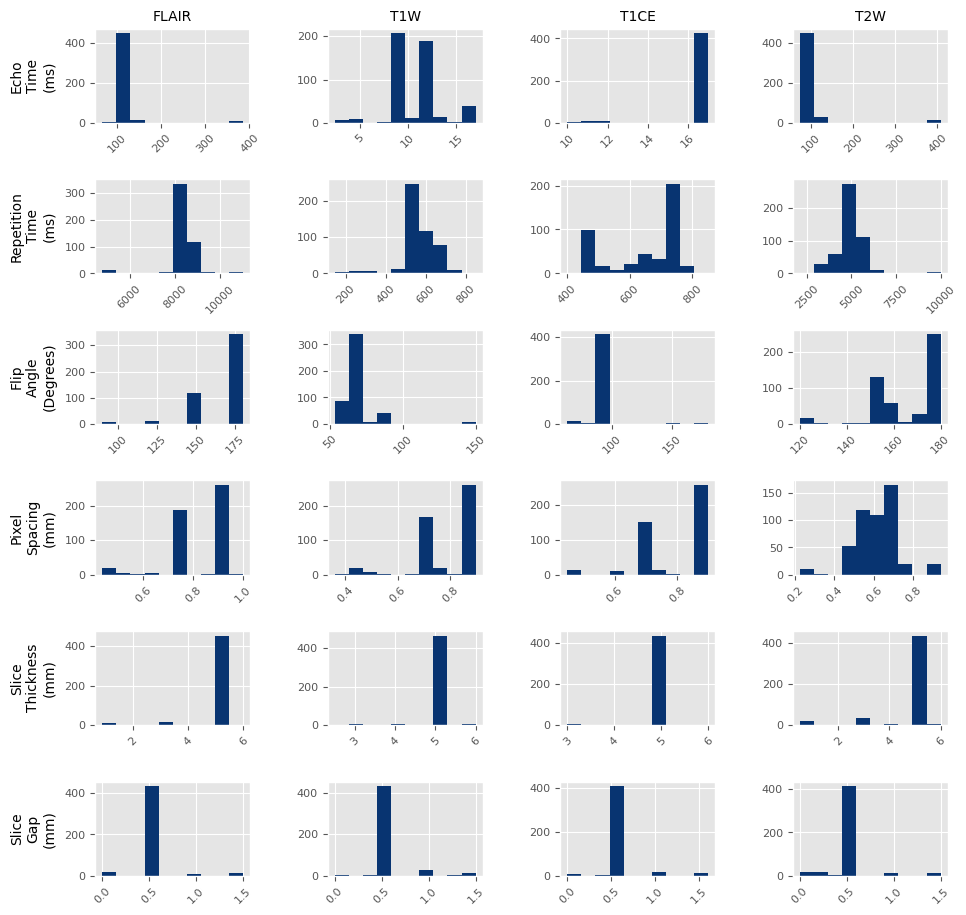

In [16]:
# ============================================================
# QUICK COUNTS
# ============================================================
sequence_counts = {
    "FLAIR": int(FLAIR_mask.sum()),
    "T1w": int(T1_mask.sum()),
    "T1wCE": int(T1CE_mask.sum()),
    "T2w": int(T2_mask.sum()),
    #"MPRAGE": int(MPRAGE_mask.sum())
}

print("Sequence counts:")
for k, v in sequence_counts.items():
    print(f"{k}: {v}")

# ============================================================
# LARGE HISTOGRAM PLOT
# ============================================================
c = "#083471"

parameters = [
    ('EchoTime', 'Echo\nTime\n(ms)'),
    ('RepetitionTime', 'Repetition\nTime\n(ms)'),
    ('FlipAngle', 'Flip\nAngle\n(Degrees)'),
    ('PixelSpacing', 'Pixel\nSpacing\n(mm)'),
    ('SliceThickness', 'Slice\nThickness\n(mm)'),
    ('SpacingBetweenSlices', 'Slice\nGap\n(mm)')
]

sequences = [
    (FLAIR_mask, 'FLAIR'),
    (T1_mask, 'T1W'),
    (T1CE_mask, 'T1CE'),
    (T2_mask, 'T2W'),
    # (MPRAGE_mask, 'MPRAGE')
]

fig, axs = plt.subplots(nrows=6, ncols=len(sequences), figsize=(11, 11))
plt.rcParams.update({'font.size': 8})
plt.subplots_adjust(hspace=0.6, wspace=0.5)

for i in range(axs.shape[0]):
    for j in range(axs.shape[1]):
        ax = axs[i, j]
        col = parameters[i][0]
        mask = sequences[j][0]

        data_selected_masked = data_selected.loc[mask, col].dropna().astype(float)

        ax.hist(data_selected_masked, color=c)
        ax.tick_params(axis='x', rotation=45)

# Column titles
for j, ax in enumerate(axs[0]):
    ax_title = sequences[j][1]
    ax.text(
        0.5, 1.2, ax_title,
        ha='center', va='top',
        transform=ax.transAxes,
        size=10
    )

# Row titles
for i, ax in enumerate(axs[:, 0]):
    ax_title = parameters[i][1]
    ax.text(
        -0.4, 0.5, ax_title,
        ha='center', va='center',
        rotation='vertical',
        transform=ax.transAxes,
        size=10
    )

plt.savefig(output_dir / "parameters_full_tfr_only.tiff", dpi=100, bbox_inches='tight')
plt.savefig(output_dir / "parameters_full_tfr_only.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

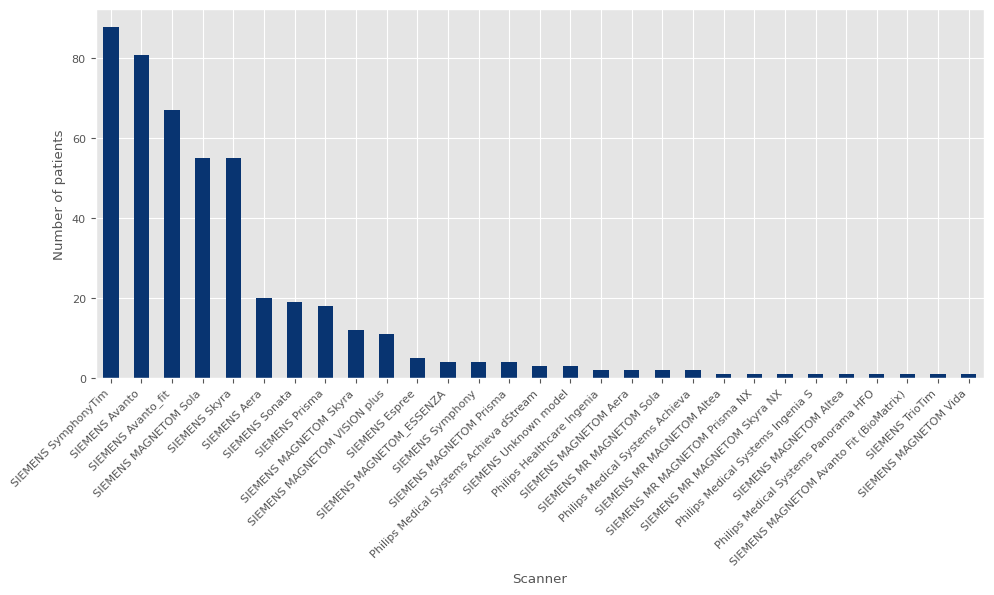

In [14]:
# ============================================================
# OPTIONAL: SCANNER BAR PLOT
# ============================================================
scanner_per_patient = (
    data_selected[["PatientID_norm", "Manufacturer", "ManufacturerModelName", "MagneticFieldStrength", "scanner"]]
    .drop_duplicates()
    .copy()
)

# choose one row per patient with most complete information
scanner_per_patient["info_score"] = scanner_per_patient[
    ["Manufacturer", "ManufacturerModelName", "MagneticFieldStrength"]
].notna().sum(axis=1)

scanner_per_patient = (
    scanner_per_patient
    .sort_values(["PatientID_norm", "info_score"], ascending=[True, False])
    .drop_duplicates(subset=["PatientID_norm"])
)

scanner_counts = scanner_per_patient["scanner"].value_counts()

plt.figure(figsize=(10, 6))
scanner_counts.plot(kind="bar", color=c)
plt.ylabel("Number of patients")
plt.xlabel("Scanner")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "scanner_distribution_tfr_only.png", dpi=150, bbox_inches="tight")
plt.savefig(output_dir / "scanner_distribution_tfr_only.tiff", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Quick sanity check

In [15]:
print(data_selected[["PatientID_norm", "SeriesDescription", "Manufacturer", "ManufacturerModelName"]].head(20))
print(data_selected[["EchoTime", "RepetitionTime", "FlipAngle", "PixelSpacing", "SliceThickness", "SpacingBetweenSlices"]].isna().mean())

   PatientID_norm                   SeriesDescription Manufacturer  \
0        95001254                           T1 cor KM      SIEMENS   
1        95001254                 T2 tirm axial flair      SIEMENS   
2        95001254                         T1 axial KM      SIEMENS   
3        95001254      PosDisp: T2 tirm axial flair 2      SIEMENS   
4        95001254      PosDisp: T2 tirm axial flair 2      SIEMENS   
5        95001254                            T1 axial      SIEMENS   
6        95001254                    T2 tse axial 512      SIEMENS   
7        95001254                PosDisp: T1 cor KM 7      SIEMENS   
13       01990699                       EvaSeries_GLM      SIEMENS   
14       01990699                fMRI Satzgenerierung      SIEMENS   
15       01990699                fMRI Verbgenerierung      SIEMENS   
16       01990699                T2 flair space3d sag      SIEMENS   
17       01990699                       Tof3d mra tra      SIEMENS   
18       01990699   

## Get Model Names for Paper

In [17]:
scanner_summary = (
    scanner_per_patient
    .groupby(["Manufacturer", "ManufacturerModelName", "MagneticFieldStrength"])
    .size()
    .reset_index(name="n_patients")
    .sort_values("n_patients", ascending=False)
)

display(scanner_summary)

,Manufacturer,ManufacturerModelName,MagneticFieldStrength,n_patients
27,SIEMENS,SymphonyTim,1.5,88
7,SIEMENS,Avanto,1.5,81
8,SIEMENS,Avanto_fit,1.5,67
15,SIEMENS,MAGNETOM Sola,1.5,55
24,SIEMENS,Skyra,3.0,55
6,SIEMENS,Aera,1.5,20
25,SIEMENS,Sonata,1.5,19
23,SIEMENS,Prisma,3.0,18
14,SIEMENS,MAGNETOM Skyra,3.0,12
16,SIEMENS,MAGNETOM VISION plus,1.5,11
